In [1]:
!pip install pandas seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [23]:
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import classification_report, balanced_accuracy_score

In [32]:
RANDOM_SEED = 37
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
visus_folder_name = 'visualizations'
os.makedirs(visus_folder_name, exist_ok=True)
visus_path = os.path.join(os.getcwd(), visus_folder_name)

In [4]:
base_path = "evaluation"
cenarios = ["zero-shot", "few-shot"]
dados = []

for cenario in cenarios:
    cenario_path = os.path.join(base_path, cenario)
    
    for root, dirs, files in os.walk(cenario_path):
        for file in files:
            if file == "individual_metrics.json":
                file_path = os.path.join(root, file)
                
                with open(file_path, "r", encoding="utf-8") as f:
                    metrics = json.load(f)
                
                for modelo, valores in metrics.items():
                    dados.append({
                        "cenario": cenario,
                        "modelo": modelo,
                        **valores
                    })

df_individuals = pd.DataFrame(dados)

model_short_names = {
    'gemma-3-gaia-pt-br-4b-it': 'Gaia',
    'mixtral-8x7b-instruct': 'Mixtral',
    'sabia-3.1': 'Sabiá',
    'granite-3-3-8b-instruct': 'Granite',
    'gemini-2.5-flash': 'Gemini',
    'gpt-4': 'GPT-4',
    'llama-3-405b-instruct': 'LLaMA',
    'deepseek-r1-0528-qwen3-8b': 'DeepSeek',
    'gervasio-7b-portuguese-ptbr-decoder': 'Gervasio',
    'kimi-k2-0905': 'Kimi'
}

df_individuals['modelo'] = df_individuals['modelo'].apply(lambda model_name: model_short_names[model_name])
df_individuals.head(3)

,cenario,modelo,punchlines,comic_styles,texts_explanations
0,zero-shot,Gaia,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
1,zero-shot,Mixtral,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
2,zero-shot,Sabiá,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...


In [5]:
def expand_dict_column(df, dict_col):
    df = df.copy()
    df[dict_col] = df[dict_col].apply(
        lambda x: x if isinstance(x, list) else [x] if isinstance(x, dict) else []
    )

    expanded_rows = []
    for _, row in df.iterrows():
        for item in row[dict_col]:
            if isinstance(item, dict):
                expanded_rows.append({
                    "scenario": row["cenario"],
                    **item
                })

    return pd.DataFrame(expanded_rows)

df_punchlines = expand_dict_column(df_individuals, "punchlines")
df_comic_styles = expand_dict_column(df_individuals, "comic_styles")
df_texts_explanations = expand_dict_column(df_individuals, "texts_explanations")
df_texts_explanations['agreement_level'] = df_texts_explanations['judge_model_results'].apply(lambda judge_model_result: int(judge_model_result['nivel_concordancia']))

### Erros e acertos em comum 

In [6]:
MIN_MODELS_REPEATS = 5

WORSE_PUNCHLINES_THRESHOLD = 0.4
BETTER_PUNCHLINES_THRESHOLD = 0.6

WORSE_EXPLANATIONS_THRESHOLD = 2
BETTER_EXPLANATIONS_THRESHOLD = 4

##### Punchlines Identification

In [7]:
df_punchlines_worse = df_punchlines[df_punchlines['dice_similarity'] <= WORSE_PUNCHLINES_THRESHOLD]
df_punchlines_better = df_punchlines[df_punchlines['dice_similarity'] >= BETTER_PUNCHLINES_THRESHOLD]

In [46]:
df_punchlines_worse['model_name'].unique()

array(['gemma-3-gaia-pt-br-4b-it', 'mixtral-8x7b-instruct', 'sabia-3.1',
       'granite-3-3-8b-instruct', 'gemini-2.5-flash', 'gpt-4',
       'gervasio-7b-portuguese-ptbr-decoder', 'llama-3-405b-instruct',
       'kimi-k2-0905', 'deepseek-r1-0528-qwen3-8b'], dtype=object)

In [57]:
models = ['gemma-3-gaia-pt-br-4b-it', 'gervasio-7b-portuguese-ptbr-decoder', 'deepseek-r1-0528-qwen3-8b']
for model in models:
    print(f'MODELO {model}')
    worse_examples = df_punchlines_worse[df_punchlines_worse['model_name'] == model].sample(10, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['cleaned_prediction']
    actual_punchlines = worse_examples['annotated_punchlines']

    for i in range(len(worse_examples)):
        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gemma-3-gaia-pt-br-4b-it
CLEANED PREDICTIONS:

["Vou dar uma chupada em você",
"Vou afundar sua moleira"]

ACTUAL PUNCHLINES:
A entrevista de Leonardo no programa Xuxa Park.; Vou afundar sua moleira.
---
CLEANED PREDICTIONS:

["É isso, minha avó dizia que se você passasse na pele dava AIDS."]
["espero que seja O positivo. Amém."]

ACTUAL PUNCHLINES:
Hoje em dia eu sou hipocondríaco, é doideira.; Espero que seja O positivo. 
---
CLEANED PREDICTIONS:

["Ó os maconheiros aí reagindo",
"Vixe, vou morrer, vou infartar, vou infartar, vou infartar, vou infartar",
"Bateu, bateu, bateu, bateu a bad, bateu a bad, bateu a bad",
"Por que que eu sei disso? Vi no documentário",
"Drauzio Dichava apareceu lá",
"Uma planta, né? Entendi"]

ACTUAL PUNCHLINES:
Né idoso de 24 anos, que já tá cheio de problema no ciático, peda no rim pra caralho, tomando tramal, reclamando de as crise de ansiedade batendo e fumando maconha, ficando com gases pra caralho. Ó os maconheiros aí reagindo.; Aí toma um sal,

##### Humor Reasoning

In [8]:
df_explanations_worse = df_texts_explanations[df_texts_explanations['agreement_level'] <= WORSE_EXPLANATIONS_THRESHOLD]
df_explanations_better = df_texts_explanations[df_texts_explanations['agreement_level'] <= BETTER_EXPLANATIONS_THRESHOLD]

##### Comic Styles Classification

In [9]:
df = df_comic_styles.copy()
rows = []

for (model, scenario, style), group in df.groupby(['model_name', 'scenario', 'comic_style']):
    y_true = group['true_label']
    y_pred = group['pred_label']
    
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    rows.append({
        'model_name': model,
        'scenario': scenario,
        'comic_style': style,
        'f1_0': report['0']['f1-score'],
        'f1_1': report['1']['f1-score'],
        'f1_macro': report['macro avg']['f1-score'],
        'balanced_accuracy': bal_acc
    })

results = pd.DataFrame(rows)
results['model_name'] = results['model_name'].apply(lambda model_name: model_short_names[model_name])

In [10]:
model_order = [
    'Gemini',
    'GPT-4',
    'Kimi-K2',
    'Sabiá',
    'LLaMA',
    'Granite',
    'Gaia',
    'Mixtral',
    'DeepSeek',
    'Gervasio'
]

results['model_name'] = pd.Categorical(results['model_name'], categories=model_order, ordered=True)

/tmp/ipykernel_27541/56039793.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
/tmp/ipykernel_27541/56039793.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
/tmp/ipykernel_27541/56039793.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
/tmp/ipykernel_27541/56039793.py:10: FutureWarning: The default value of 

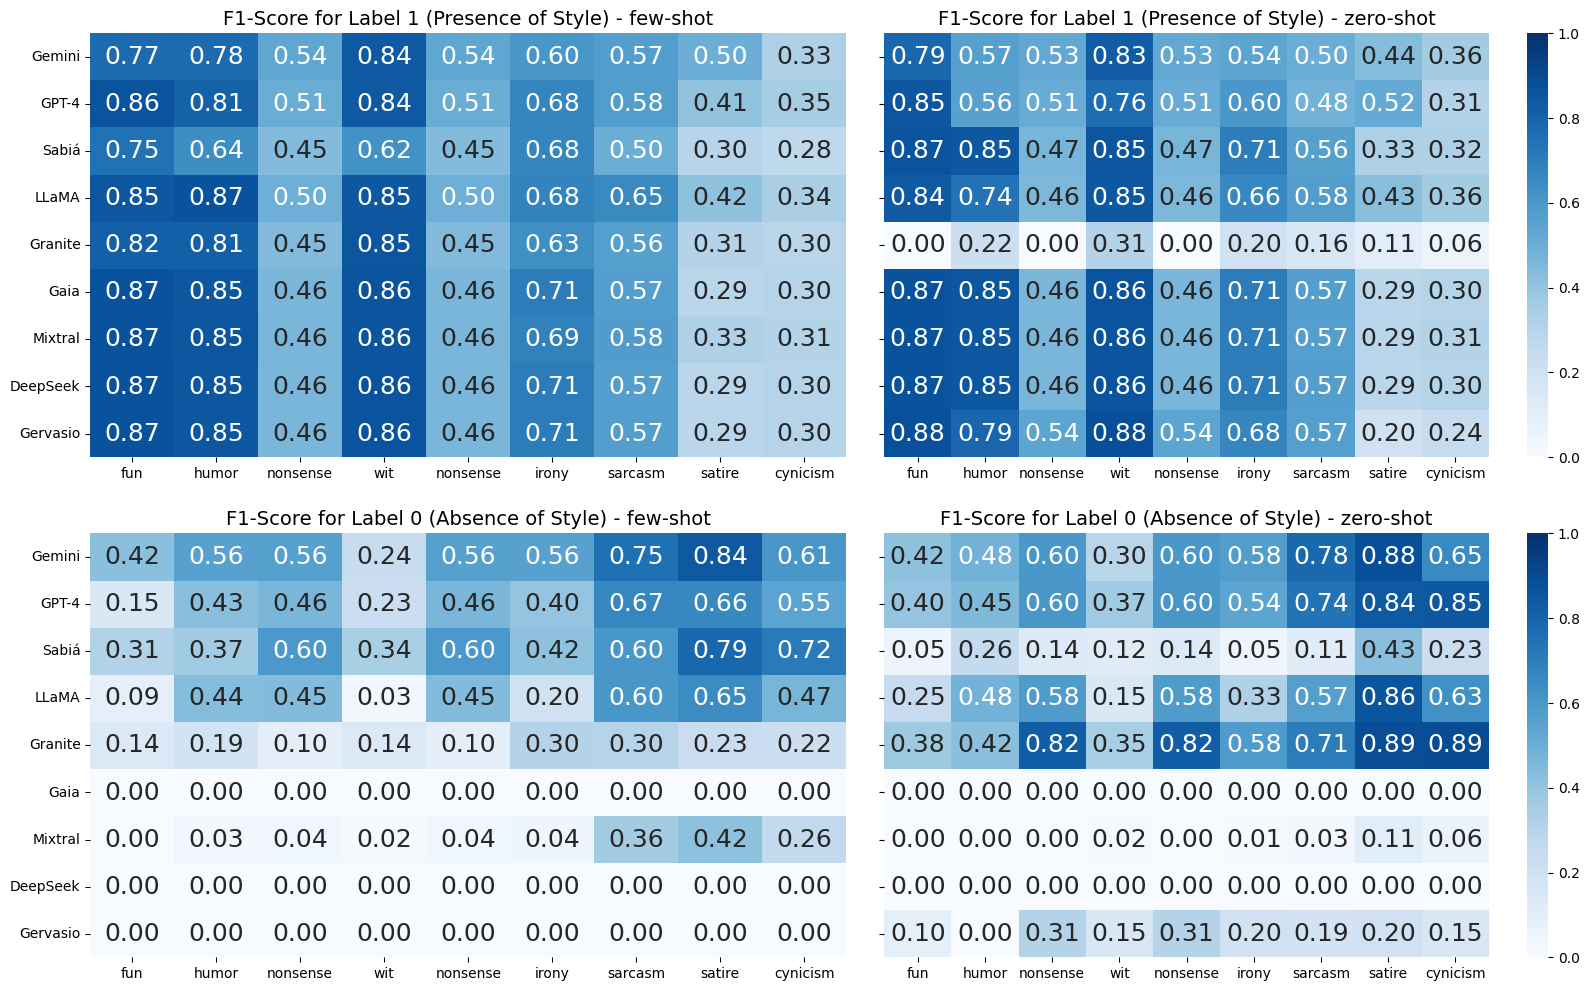

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), sharey=True)
f1_info = [('f1_1', 'Label 1 (Presence of Style)'), ('f1_0', 'Label 0 (Absence of Style)')]
scenarios = results['scenario'].unique()
style_order = ['fun', 'humor', 'nonsense', 'wit', 'nonsense', 'irony', 'sarcasm', 'satire', 'cynicism']

for row_idx, (f1_class, title) in enumerate(f1_info):
    for col_idx, scenario in enumerate(scenarios):
        ax = axes[row_idx, col_idx]

        pivot = results[results['scenario'] == scenario].pivot_table(
            index='model_name', columns='comic_style', values=f1_class, aggfunc='mean'
        )
        
        pivot = pivot.reindex(columns=style_order)

        sns.heatmap(
            pivot,
            annot=True,
            cmap='Blues',
            vmin=0,
            vmax=1,
            ax=ax,
            fmt=".2f",
            annot_kws={'size': 18},
            cbar=(col_idx == 1)
        )
        
        ax.set_title(f'F1-Score for {title} - {scenario}', fontsize=14)
        ax.set_xlabel('', fontsize=16) 
        if col_idx == 0:
            ax.set_ylabel('', fontsize=16)
        else:
            ax.set_ylabel('')

        ax.tick_params(axis='x', labelsize=10, rotation=0)
        ax.tick_params(axis='y', labelsize=10)

plt.subplots_adjust(hspace=0.18, wspace=0.05)

plt.savefig(
    os.path.join(visus_path, "comic_styles_f1_individuals.png"), 
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Salvo: /home/josegama/Downloads/brazilian_northeast_humor_benchmark/visualizations/radar_chart_per_model_f1_1.png


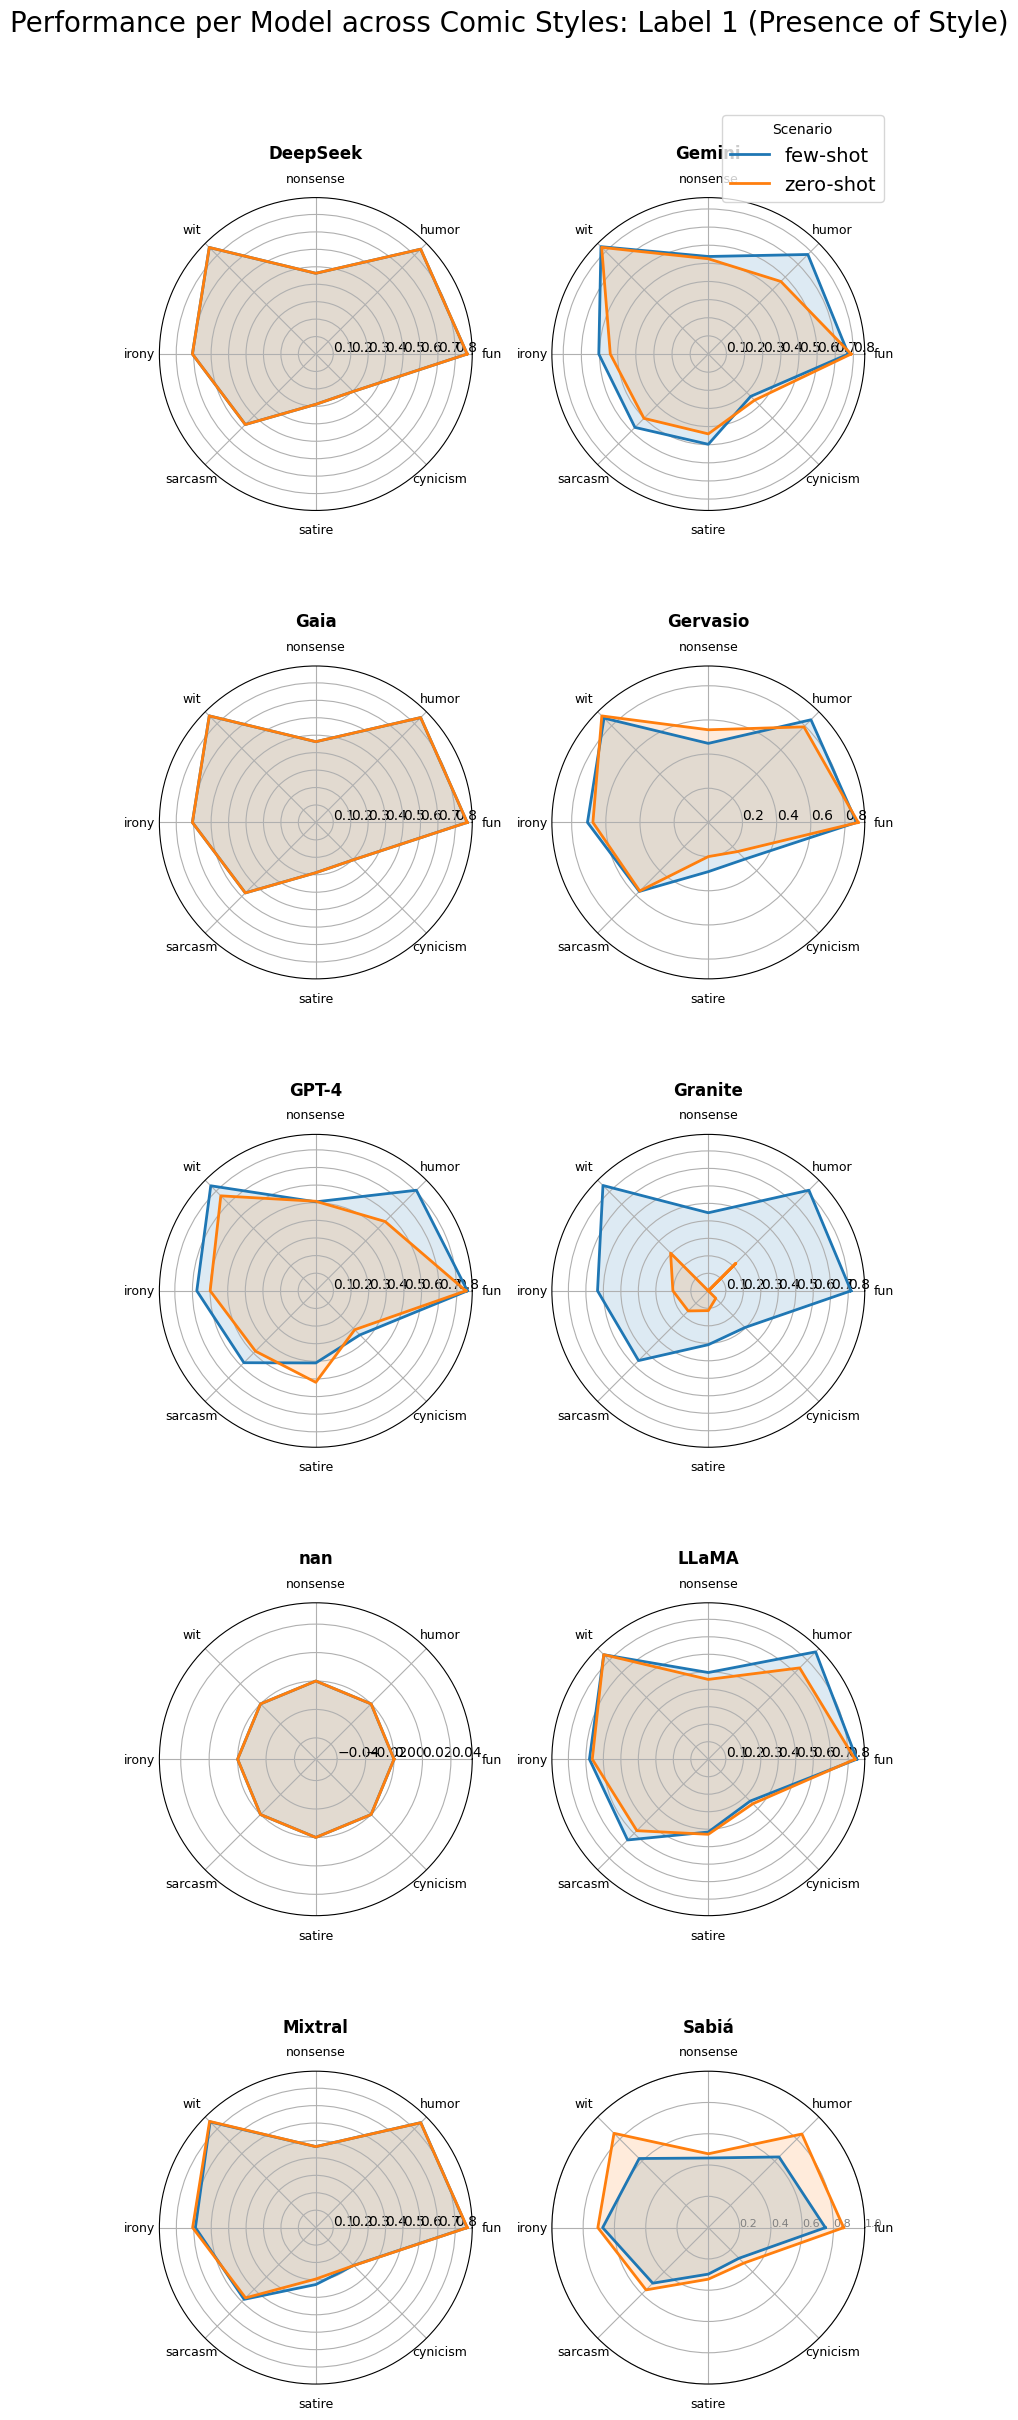

Salvo: /home/josegama/Downloads/brazilian_northeast_humor_benchmark/visualizations/radar_chart_per_model_f1_0.png


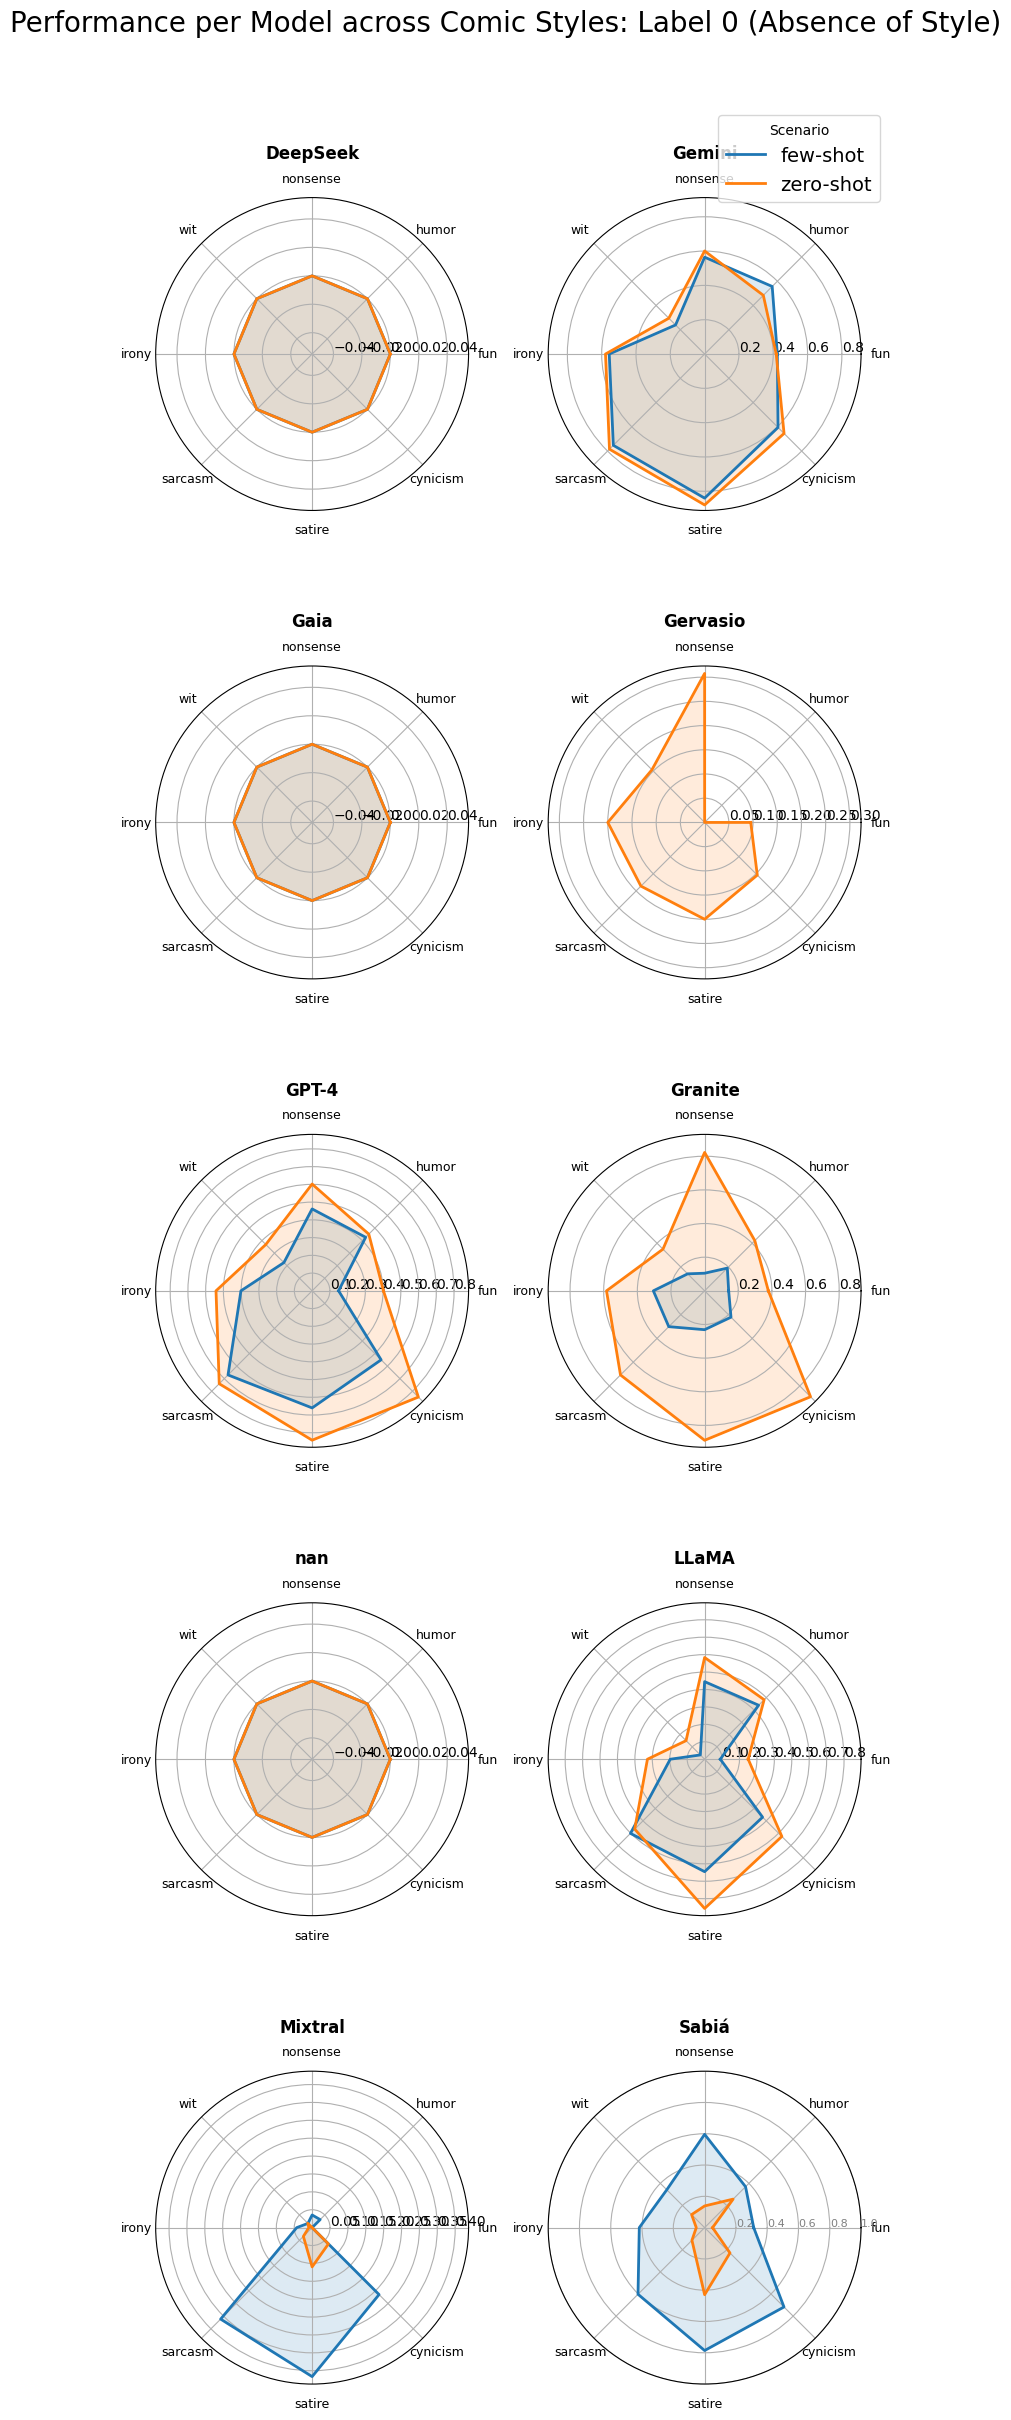

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# --- Configurações de Dados ---
# Definindo as métricas e títulos
f1_info = [('f1_1', 'Label 1 (Presence of Style)'), ('f1_0', 'Label 0 (Absence of Style)')]

# Pegar os cenários para as linhas (legendas)
scenarios = results['scenario'].unique()

# Pegar os modelos para ser cada um dos radares (subplots)
# Limita a 10 modelos conforme solicitado, ou pega todos se houver menos
models = results['model_name'].unique()

# Definir os eixos do radar (Estilos Cômicos)
# Nota: Removi a duplicata de 'nonsense' que havia na sua lista original
style_order = ['fun', 'humor', 'nonsense', 'wit', 'irony', 'sarcasm', 'satire', 'cynicism']
num_vars = len(style_order)

# --- Cálculos Geométricos do Radar ---
# Calcular o ângulo de cada eixo
angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1]  # Fechar o loop (conectar o último ponto ao primeiro)

# --- Loop de Plotagem ---
# Um loop para F1_1 e outro para F1_0
for f1_col, f1_title in f1_info:
    
    # Criar grid 2x5 (10 plots)
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(8, 24), subplot_kw=dict(polar=True))
    axes = axes.flatten() # Vetorizar para facilitar iteração
    
    colors = ['#1f77b4', '#ff7f0e'] # Azul (Zero-shot) e Laranja (Few-shot)
    
    # Iterar sobre os Modelos (Cada modelo ganha um Radar)
    for idx, model in enumerate(models):
        if idx >= len(axes): break # Garante que não estoure o limite de 10 plots
        
        ax = axes[idx]
        
        # Iterar sobre os Cenários (Linhas dentro do radar)
        for s_idx, scenario in enumerate(scenarios):
            
            # Filtrar dados específicos: Modelo X, Cenário Y
            subset = results[
                (results['model_name'] == model) & 
                (results['scenario'] == scenario)
            ]
            
            # Precisamos garantir a ordem correta dos estilos nos eixos
            # Criamos um dict {estilo: valor} para mapear corretamente
            val_map = dict(zip(subset['comic_style'], subset[f1_col]))
            
            # Monta a lista de valores na ordem de 'style_order'
            # Se um estilo não existir para aquele modelo, assume 0
            values = [val_map.get(s, 0) for s in style_order]
            
            # Fechar o polígono repetindo o primeiro valor no final
            values += values[:1]
            
            # Plotar linha e preenchimento
            ax.plot(angles, values, linewidth=2, linestyle='solid', label=scenario, color=colors[s_idx % len(colors)])
            ax.fill(angles, values, color=colors[s_idx % len(colors)], alpha=0.15)
        
        # --- Formatação do Radar Individual ---
        # Labels dos eixos (Estilos)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(style_order, fontsize=9)
        
        # Labels da grade radial (Valores Y)
        ax.set_rlabel_position(0)
        plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
        plt.ylim(0, 1)
        
        # Título do Subplot (Nome do Modelo)
        # O split serve para quebrar nomes muito longos se houver espaços/barras
        ax.set_title(model, size=12, fontweight='bold', y=1.1)

    # --- Limpeza Final ---
    # Remover subplots vazios se tiver menos de 10 modelos
    for i in range(len(models), len(axes)):
        fig.delaxes(axes[i])

    # Legenda Global
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=14, title="Scenario")

    # Título Geral da Figura
    fig.suptitle(f'Performance per Model across Comic Styles: {f1_title}', fontsize=20, y=1.02)
    
    plt.tight_layout()
    
    # Salvar
    filename = f"radar_chart_per_model_{f1_col}.png"
    save_path = os.path.join(visus_path, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Salvo: {save_path}")
    plt.show()

In [13]:
comic_styles = df_comic_styles['comic_style'].unique()

print(comic_styles)

# O código abaixo cria dois dataframe de para cada estilo cômico, um de piores casos e outro de melhores. 
# Ex.: df_fun_worse, df_fun_better, df_irony_worse, df_irony_better.

for style in comic_styles:
    df_name_worse = f"df_{style}_worse"
    df_name_better = f"df_{style}_better"
    globals()[df_name_worse] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 0)]
    globals()[df_name_better] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 1)]

['fun' 'humor' 'nonsense' 'wit' 'irony' 'satire' 'sarcasm' 'cynicism']
